# Gaussian Mixture Model Demo
Info on Gaussian mixture model from scikit-learn: https://scikit-learn.org/stable/modules/mixture.html#gmm

In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold

colors = ["navy", "turquoise", "darkorange"]


def make_ellipses(gmm, ax):
    for n, color in enumerate(colors):
        if gmm.covariance_type == "full":
            covariances = gmm.covariances_[n][:2, :2]
        elif gmm.covariance_type == "tied":
            covariances = gmm.covariances_[:2, :2]
        elif gmm.covariance_type == "diag":
            covariances = np.diag(gmm.covariances_[n][:2])
        elif gmm.covariance_type == "spherical":
            covariances = np.eye(gmm.means_.shape[1]) * gmm.covariances_[n]
        v, w = np.linalg.eigh(covariances)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180 * angle / np.pi  # convert to degrees
        v = 2.0 * np.sqrt(2.0) * np.sqrt(v)
        ell = mpl.patches.Ellipse(
            gmm.means_[n, :2], v[0], v[1], angle=180 + angle, color=color
        )
        ell.set_clip_box(ax.bbox)
        ell.set_alpha(0.5)
        ax.add_artist(ell)
        ax.set_aspect("equal", "datalim")


In [2]:
iris = datasets.load_iris()

# Break up the dataset into non-overlapping training (75%) and testing
# (25%) sets.
skf = StratifiedKFold(n_splits=4)
# Only take the first fold.
train_index, test_index = next(iter(skf.split(iris.data, iris.target)))


X_train = iris.data[train_index]
y_train = iris.target[train_index]
X_test = iris.data[test_index]
y_test = iris.target[test_index]

n_classes = len(np.unique(y_train))

# Try GMMs using different types of covariances.
estimators = {
    cov_type: GaussianMixture(
        n_components=n_classes, covariance_type=cov_type, max_iter=20, random_state=0
    )
    for cov_type in ["spherical", "diag", "tied", "full"]
}

n_estimators = len(estimators)

C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmea

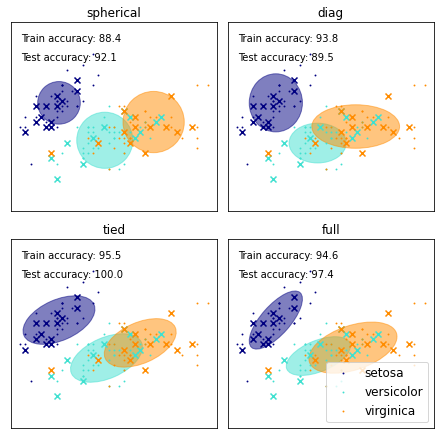

In [3]:
plt.figure(figsize=(3 * n_estimators // 2, 6))
plt.subplots_adjust(
    bottom=0.01, top=0.95, hspace=0.15, wspace=0.05, left=0.01, right=0.99
)
for index, (name, estimator) in enumerate(estimators.items()):
    # Since we have class labels for the training data, we can
    # initialize the GMM parameters in a supervised manner.
    estimator.means_init = np.array(
        [X_train[y_train == i].mean(axis=0) for i in range(n_classes)]
    )

    # Train the other parameters using the EM algorithm.
    estimator.fit(X_train)

    h = plt.subplot(2, n_estimators // 2, index + 1)
    make_ellipses(estimator, h)

    for n, color in enumerate(colors):
        data = iris.data[iris.target == n]
        plt.scatter(
            data[:, 0], data[:, 1], s=0.8, color=color, label=iris.target_names[n]
        )
    # Plot the test data with crosses
    for n, color in enumerate(colors):
        data = X_test[y_test == n]
        plt.scatter(data[:, 0], data[:, 1], marker="x", color=color)

    y_train_pred = estimator.predict(X_train)
    train_accuracy = np.mean(y_train_pred.ravel() == y_train.ravel()) * 100
    plt.text(0.05, 0.9, "Train accuracy: %.1f" % train_accuracy, transform=h.transAxes)

    y_test_pred = estimator.predict(X_test)
    test_accuracy = np.mean(y_test_pred.ravel() == y_test.ravel()) * 100
    plt.text(0.05, 0.8, "Test accuracy: %.1f" % test_accuracy, transform=h.transAxes)

    plt.xticks(())
    plt.yticks(())
    plt.title(name)

plt.legend(scatterpoints=1, loc="lower right", prop=dict(size=12))


plt.show()

Inspired by ChatGPT

In [6]:
import numpy as np
import time

# np.random.seed(0)

xmin = -10
xmax = 10
ymin = xmin
ymax = xmax

# Continuous region: one big smooth Gaussian
X_cont = np.random.uniform(
    low=xmin,
    high=xmax,
    size=(1000, 2)
)

# Discrete region: many small tight clusters
centers = np.random.uniform(xmin, xmax, size=(10, 2))
# print(centers)
X_disc = np.vstack([
    np.random.multivariate_normal(c, [[0.05, 0], [0, 0.05]], size=2000)
    for c in centers
])

X_both = np.vstack([X_disc, X_cont])

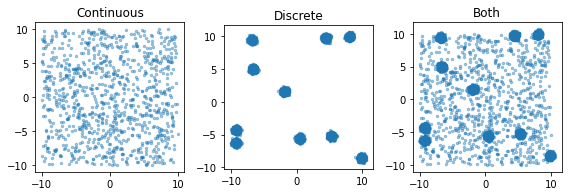

In [7]:
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(131)
ax1.scatter(X_cont[:, 0], X_cont[:, 1], s=6, alpha=0.4)
ax1.set_title('Continuous')
ax1.set_aspect('equal')
ax2 = fig.add_subplot(132)
ax2.scatter(X_disc[:, 0], X_disc[:, 1], s=6, alpha=0.4)
ax2.set_title('Discrete')
ax2.set_aspect('equal')
ax3 = fig.add_subplot(133)
ax3.scatter(X_both[:, 0], X_both[:, 1], s=6, alpha=0.4)
ax3.set_title('Both')
ax3.set_aspect('equal')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.mixture import GaussianMixture

def gmm_est(X, Kmax=12):
    gmms = []
    losses = []    
    for k in range(1, Kmax + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            reg_covar=1e-6,
            n_init=5
        )
        gmm.fit(X)
        loss = gmm.score(X)
        
        gmms.append(gmm)
        losses.append(loss)
    return gmms, losses

In [9]:
Kmax = 12
ks = range(1, Kmax + 1)

start = time.time()
gmms_cont, loss_cont = gmm_est(X_cont, Kmax)
gmms_disc, loss_disc = gmm_est(X_disc, Kmax)
gmms_both, loss_both = gmm_est(X_both, Kmax)

print('K_max={}'.format(Kmax))
print('Time elapsed: {:.2f} s'.format(time.time() - start))
print('Num points cont: {}'.format(X_cont.size))
print('Num points disc: {}'.format(X_disc.size))
print('Num points both: {}'.format(X_both.size))

K_max=12
Time elapsed: 22.74 s
Num points cont: 2000
Num points disc: 40000
Num points both: 42000


In [10]:
area = (xmax - xmin) * (ymax - ymin)
loss_uniform = -np.log(area)
print('Log likelihood uniform: {}'.format(loss_uniform))

Log likelihood uniform: -5.991464547107982


In [11]:
score_cont = loss_cont - loss_uniform
score_disc = loss_disc - loss_uniform
score_both = loss_both - loss_uniform

print('Score continuous: {}'.format(score_cont))
print('Score discrete: {}'.format(score_disc))
print('Score both: {}'.format(score_both))

Score continuous: [-0.31578081 -0.24523957 -0.19765389 -0.17850085 -0.14948348 -0.11350061
 -0.09085721 -0.06124049 -0.08280752 -0.03345663 -0.02316259 -0.02136669]
Score discrete: [-0.72868452  0.01156539  0.63288887  1.45019462  2.12030389  2.73501775
  3.07447411  3.39875193  3.68005082  3.84209615  3.84194839  3.84159044]
Score both: [-0.71285579 -0.03433273  0.47660961  1.13618203  1.68764332  2.02290144
  2.33282582  2.67614303  3.04994022  3.31579241  3.46696398  3.47013557]


In [12]:
K_best_cont = ks[np.argmax(score_cont)]
K_best_disc = ks[np.argmax(score_disc)]
K_best_both = ks[np.argmax(score_both)]
gmm_best_cont = gmms_cont[np.argmax(score_cont)]
gmm_best_disc = gmms_disc[np.argmax(score_disc)]
gmm_best_both = gmms_both[np.argmax(score_both)]

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def draw_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )
    ax.add_patch(ellipse)

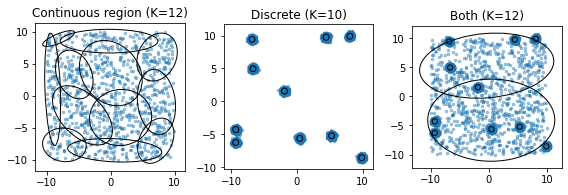

In [14]:
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(131)
ax1.scatter(X_cont[:, 0], X_cont[:, 1], s=6, alpha=0.4)
for mean, cov in zip(gmm_best_cont.means_, gmm_best_cont.covariances_):
    draw_ellipse(mean, cov, ax1)
ax1.set_title("Continuous region (K={})".format(K_best_cont))
ax1.set_aspect('equal')
ax2 = fig.add_subplot(132)
ax2.scatter(X_disc[:, 0], X_disc[:, 1], s=6, alpha=0.4)
for mean, cov in zip(gmm_best_disc.means_, gmm_best_disc.covariances_):
    draw_ellipse(mean, cov, ax2)
ax2.set_title("Discrete (K={})".format(K_best_disc))
ax2.set_aspect('equal')
ax3 = fig.add_subplot(133)
ax3.scatter(X_both[:, 0], X_both[:, 1], s=6, alpha=0.4)
for mean, cov in zip(gmm_best_both.means_, gmm_best_both.covariances_):
    draw_ellipse(mean, cov, ax3)
ax3.set_title("Both (K={})".format(K_best_both))
ax3.set_aspect('equal')
plt.tight_layout()
plt.show()

Now try with CoBaLT data

In [1]:
# Load in CoBaLT data

# Imports and project root setup
import sys
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import time
import hdbscan
from sklearn.decomposition import PCA
import numpy as np

# Determine project root: prefer __file__ when available (script), otherwise search upward for 'config/preprocessing.yaml'
def find_project_root(start_path: Path = Path.cwd()):
    p = start_path.resolve()
    for parent in [p] + list(p.parents):
        if (parent / 'config' / 'preprocessing.yaml').exists():
            return parent
    return start_path.resolve()

try:
    project_root = Path(__file__).resolve().parent.parent
except NameError:
    project_root = find_project_root()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# (Optional) configure matplotlib interactive backend, if you want interactive selectors in this notebook
# Uncomment one of the following depending on your environment:
# %matplotlib widget
# %matplotlib notebook
%matplotlib inline

# Import the DataPreprocessor class from the package
from processing.data_preprocessor_v2 import DataPreprocessor
from processing.processing_methods.data_loader import DataLoader
from processing.processing_methods.data_plotter import DataPlotter
from processing.processing_methods.data_processor import DataProcessor

# Load configuration and create the DataPreprocessor instance
config_path = project_root / 'config' / 'preprocessing_clustering.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)


Detected Windows data directory: C:\Users\Grant\OneDrive - UCB-O365\ARSENL\Experiments\Cloud Measurements\First Light
Measurement time (behind 1 hour if outside Daylight Savings): 2025-09-30 22:19:47

Preprocessed data file(s) found. No need to create new one(s)...
Locating and loading relevant netcdf data chunks...
Skipping chunk #0: 0.00–49.37s not in range 182.00–192.00s
Skipping chunk #1: 49.37–106.02s not in range 182.00–192.00s
Skipping chunk #2: 106.02–162.87s not in range 182.00–192.00s

Including chunk #3: 162.87–219.61s overlaps 182.00–192.00s
File loaded.

✅ Full time range 182.00–192.00s covered by loaded chunks.
Loaded 1 files

Starting to generate scatter plot...
Finished generating plot.
Time elapsed: 7.0 s
Starting to save image...
Finished saving plot.
Time elapsed: 3.2 s


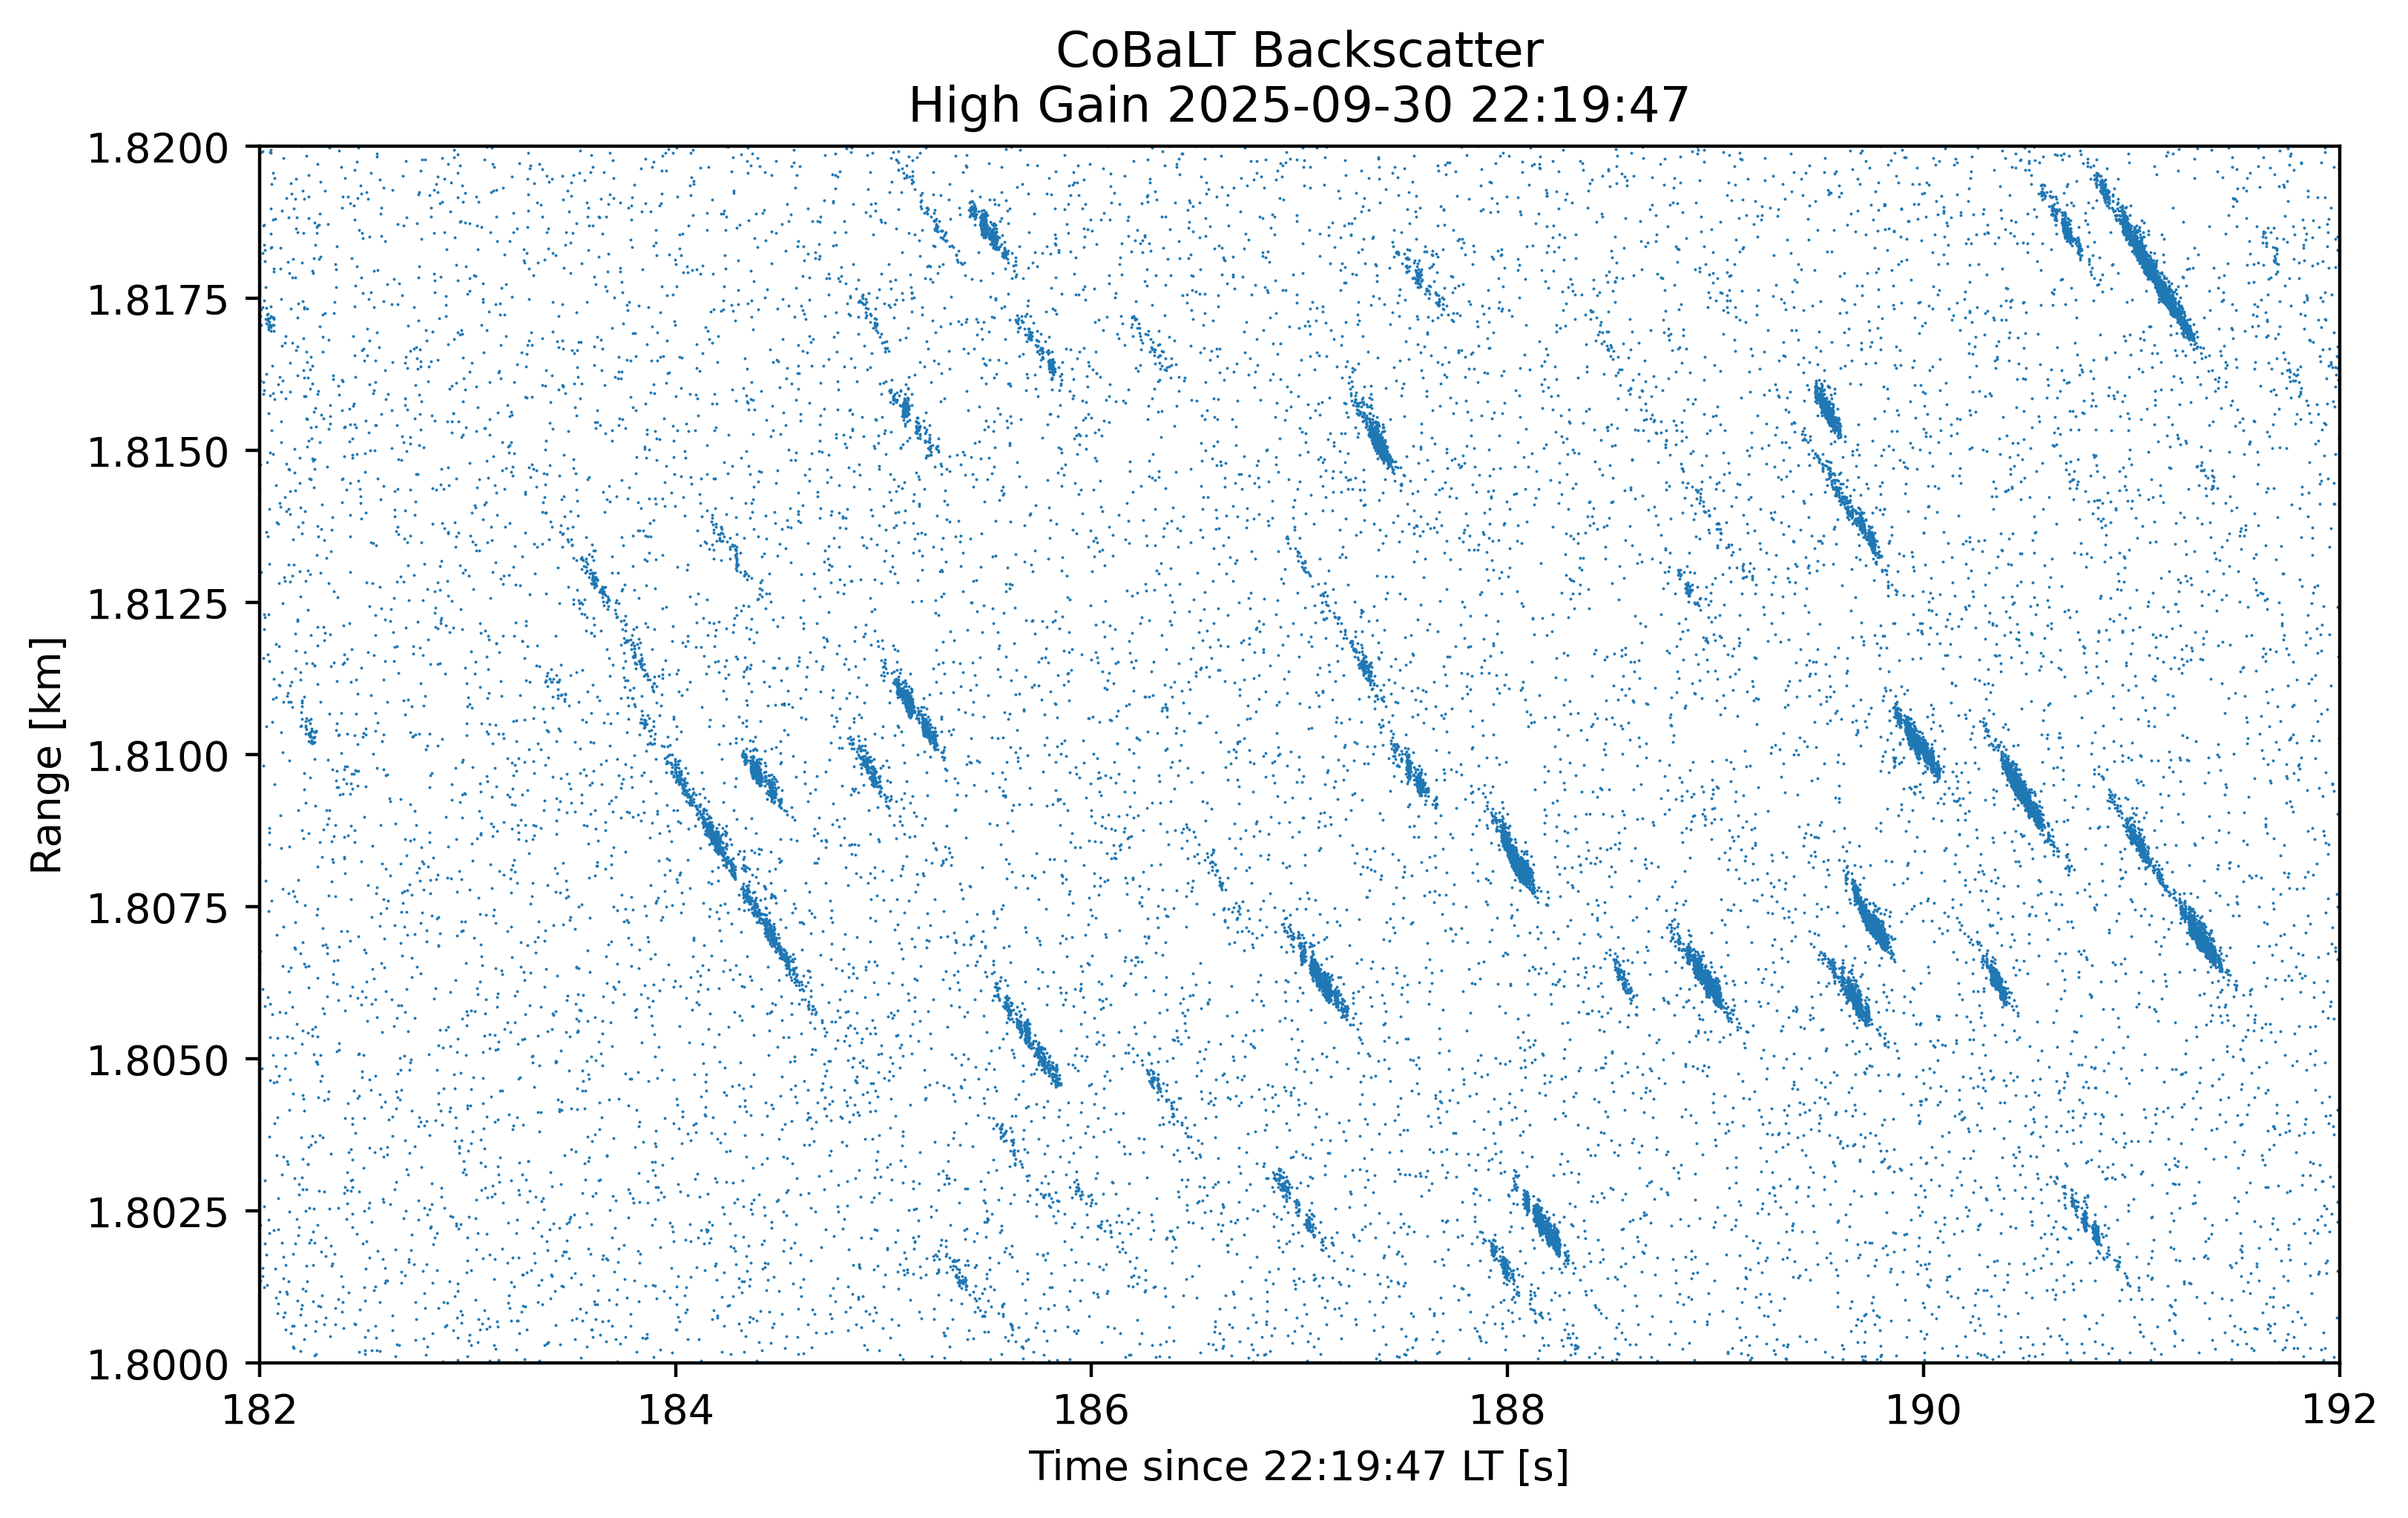

In [2]:
dp = DataPreprocessor(config)
dp.loader = DataLoader(config)
dp.plotter = DataPlotter(config)
dp.processor = DataProcessor(config)

dp.loader.preprocess()
dp.plotter.plot_scatter(dp.loader)

In [10]:
dp.loader.load_chunk()

ranges = np.concatenate([da.values.ravel() for da in dp.loader.ranges_tot])
shots_time = np.concatenate([da.values.ravel() for da in dp.loader.shots_time_tot])

Locating and loading relevant netcdf data chunks...
Skipping chunk #0: 0.00–49.37s not in range 182.00–192.00s
Skipping chunk #1: 49.37–106.02s not in range 182.00–192.00s
Skipping chunk #2: 106.02–162.87s not in range 182.00–192.00s

Including chunk #3: 162.87–219.61s overlaps 182.00–192.00s
File loaded.

✅ Full time range 182.00–192.00s covered by loaded chunks.
Loaded 1 files


In [11]:
r0, r1 = dp.loader.ylim[0] * 1e3, dp.loader.ylim[1] * 1e3  # [km]
t0, t1 = dp.loader.xlim[0], dp.loader.xlim[1]  # [s]

mask = (
    (ranges >= r0) & (ranges <= r1) &
    (shots_time  >= t0) & (shots_time  <= t1)
)

filtered_ranges = ranges[mask]
filtered_times  = shots_time[mask]

print("Number of points: {}".format(filtered_ranges.size))

Number of points: 65182


In [12]:
CoBaLT_blobs = np.array([filtered_times, filtered_ranges]).T

In [ ]:
Sig = np.cov(CoBaLT_blobs)



In [102]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(CoBaLT_blobs)
# X_reduced = PCA(n_components=2).fit_transform(X_scaled)

start = time.time()

clusterer = hdbscan.HDBSCAN(algorithm='best', alpha=1.0, approx_min_span_tree=True,
    gen_min_span_tree=False, leaf_size=40,
    metric='euclidean', min_cluster_size=50, min_samples=200, p='euclidean', cluster_selection_method='leaf')
clusterer.fit(X_scaled)

print('Time elapsed: {:.2f} s'.format(time.time() - start))

X_original = scaler.inverse_transform(X_scaled)

C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Time elapsed: 4.14 s


Num clusters: 42


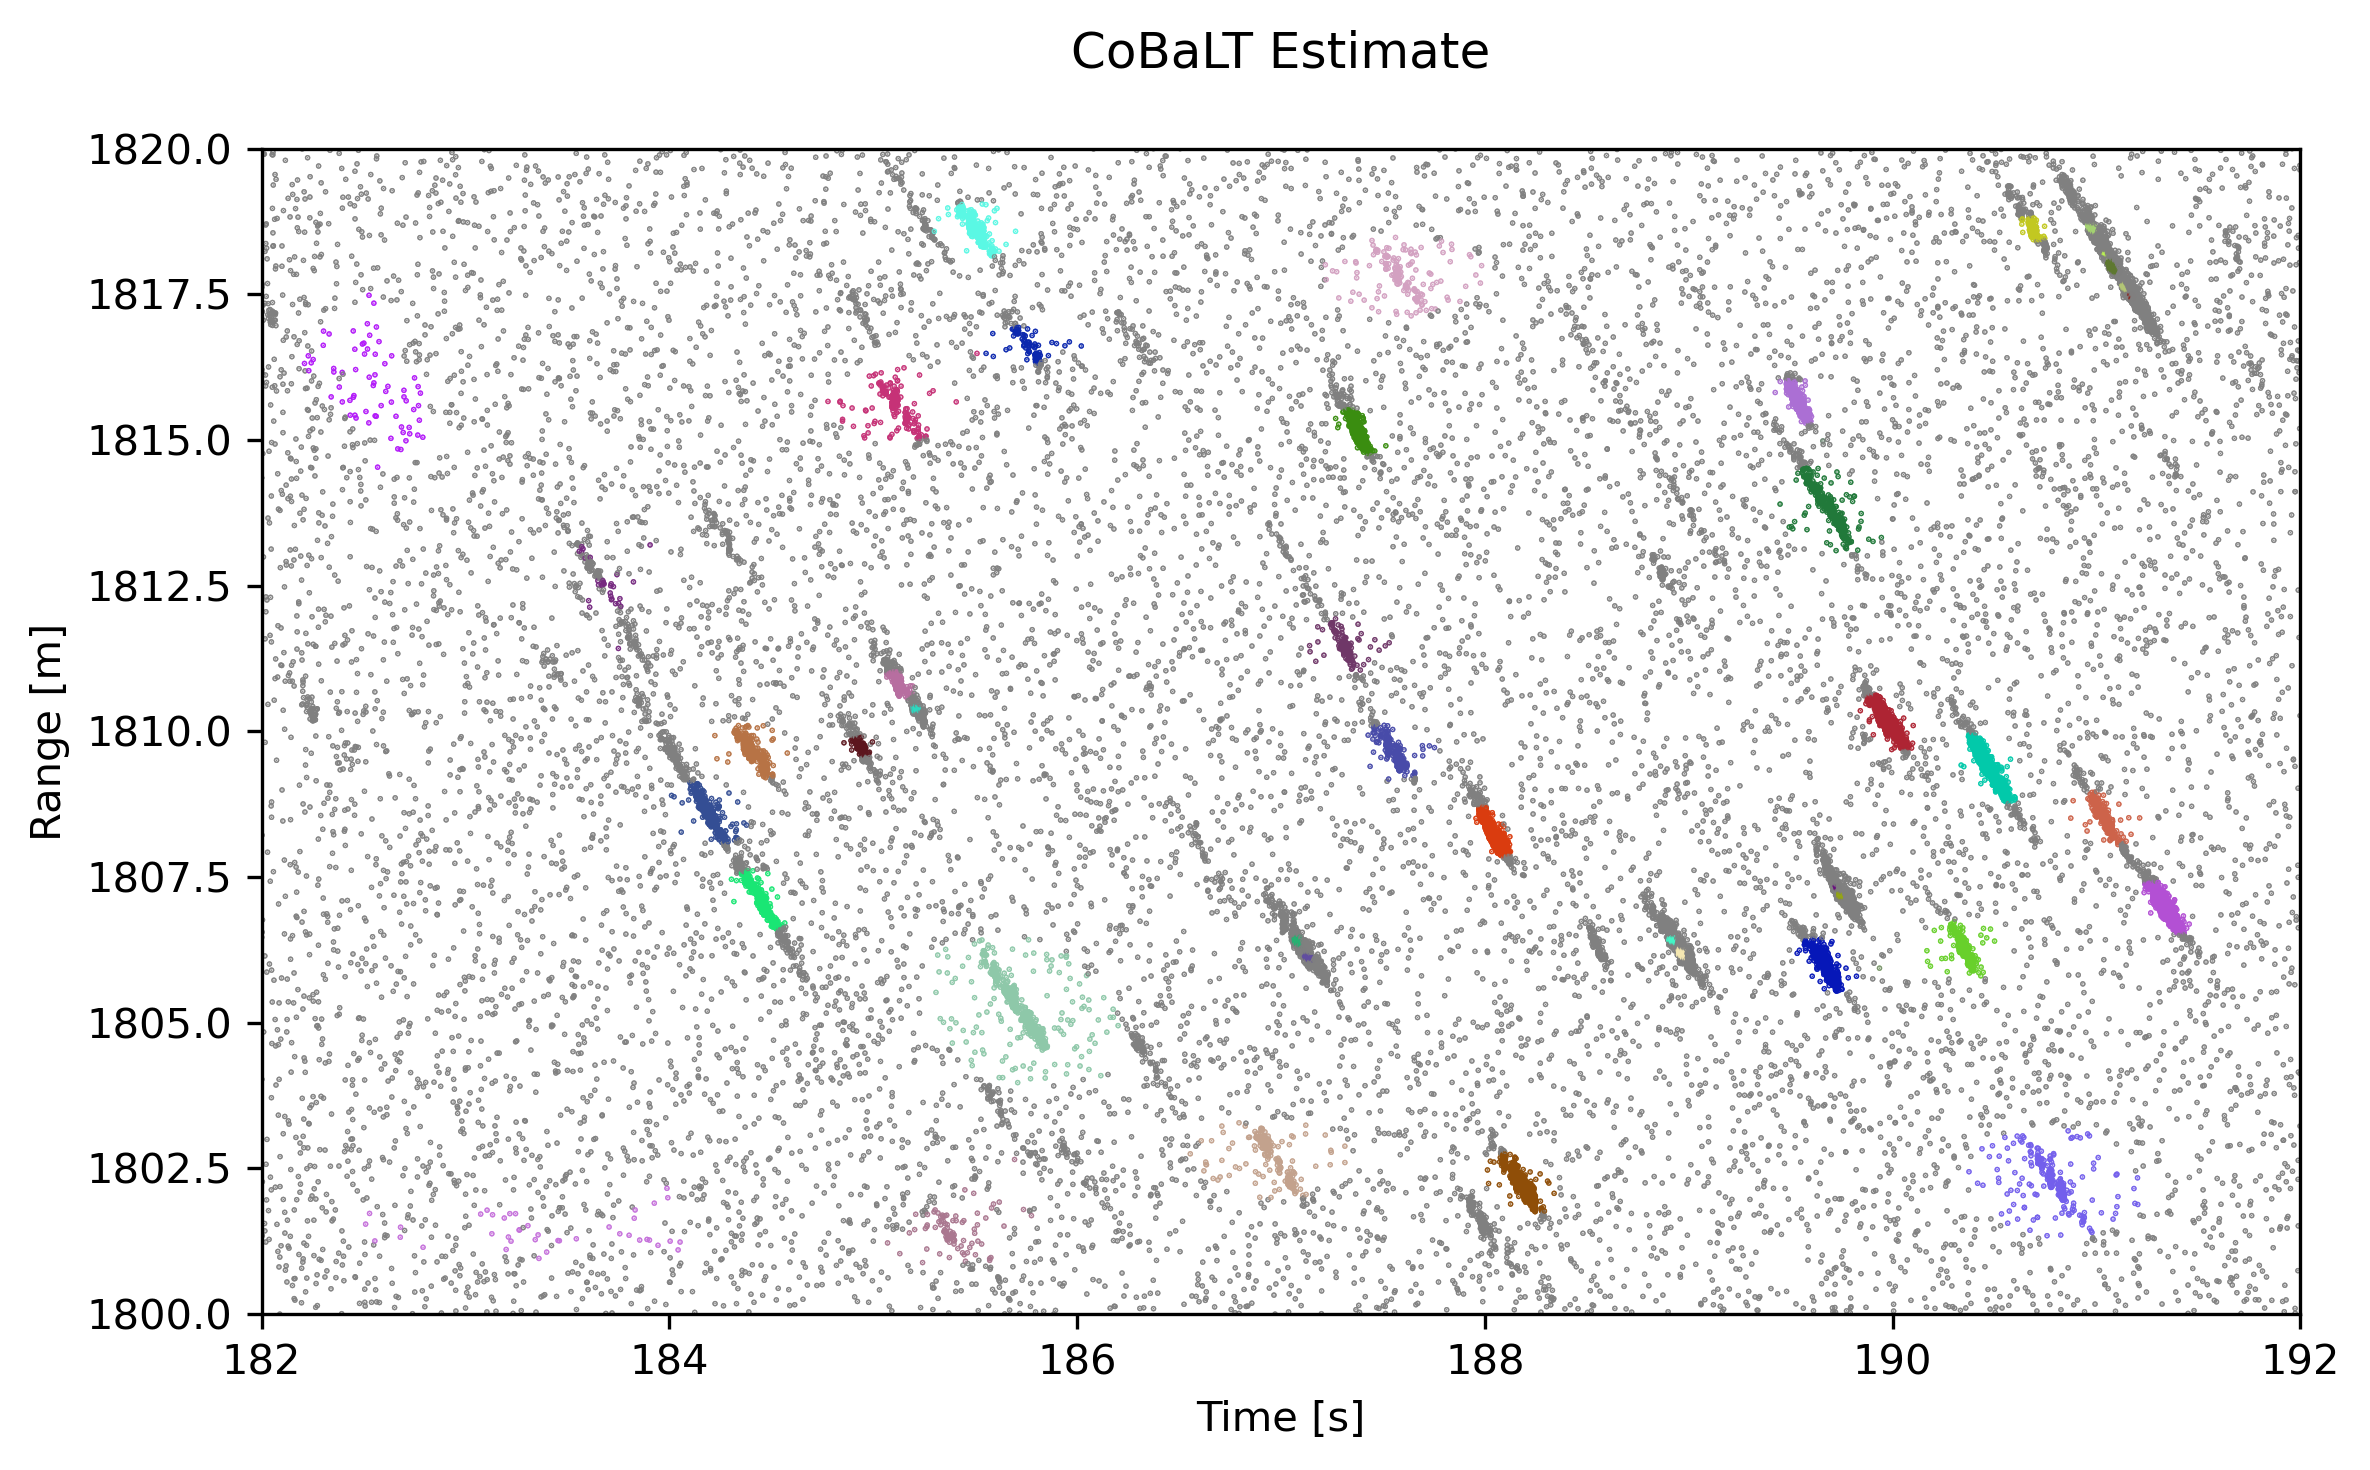

In [103]:
fig = plt.figure(figsize=(8, 5), dpi=300)
ax = fig.add_subplot(111)

labels = clusterer.labels_.copy()
labels[clusterer.probabilities_ < 0.25] = -1
unique_labels = np.unique(labels)

# Separate noise (-1) from real clusters
cluster_labels = unique_labels[unique_labels >= 0]
n_clusters = len(cluster_labels)
print('Num clusters: {}'.format(n_clusters))

# Generate random colors for real clusters
rng = np.random.default_rng(42)  # reproducible
colors = rng.random((len(cluster_labels), 3))

# Assign colors
label_to_color = {label: colors[i] for i, label in enumerate(cluster_labels)}

# Add a fixed color for noise
noise_color = np.array([0.5, 0.5, 0.5])  # gray
label_to_color[-1] = noise_color

# Build per-point color array
point_colors = np.array([label_to_color[label] for label in labels])

# scatter = ax.scatter(CoBaLT_blobs[:, 0], CoBaLT_blobs[:, 1], c=point_colors, cmap='viridis', s=5, alpha=0.8)
scatter = ax.scatter(X_original[:, 0], X_original[:, 1], c=point_colors, cmap='viridis', s=0.1, alpha=0.8)
# plt.colorbar(scatter, ax=ax, label='Cluster Label')
ax.set_title('CoBaLT Estimate\n')
ax.set_ylabel('Range [m]')
ax.set_xlabel('Time [s]')
ax.set_xlim([t0, t1])
ax.set_ylim([r0, r1])

plt.tight_layout()
plt.show()

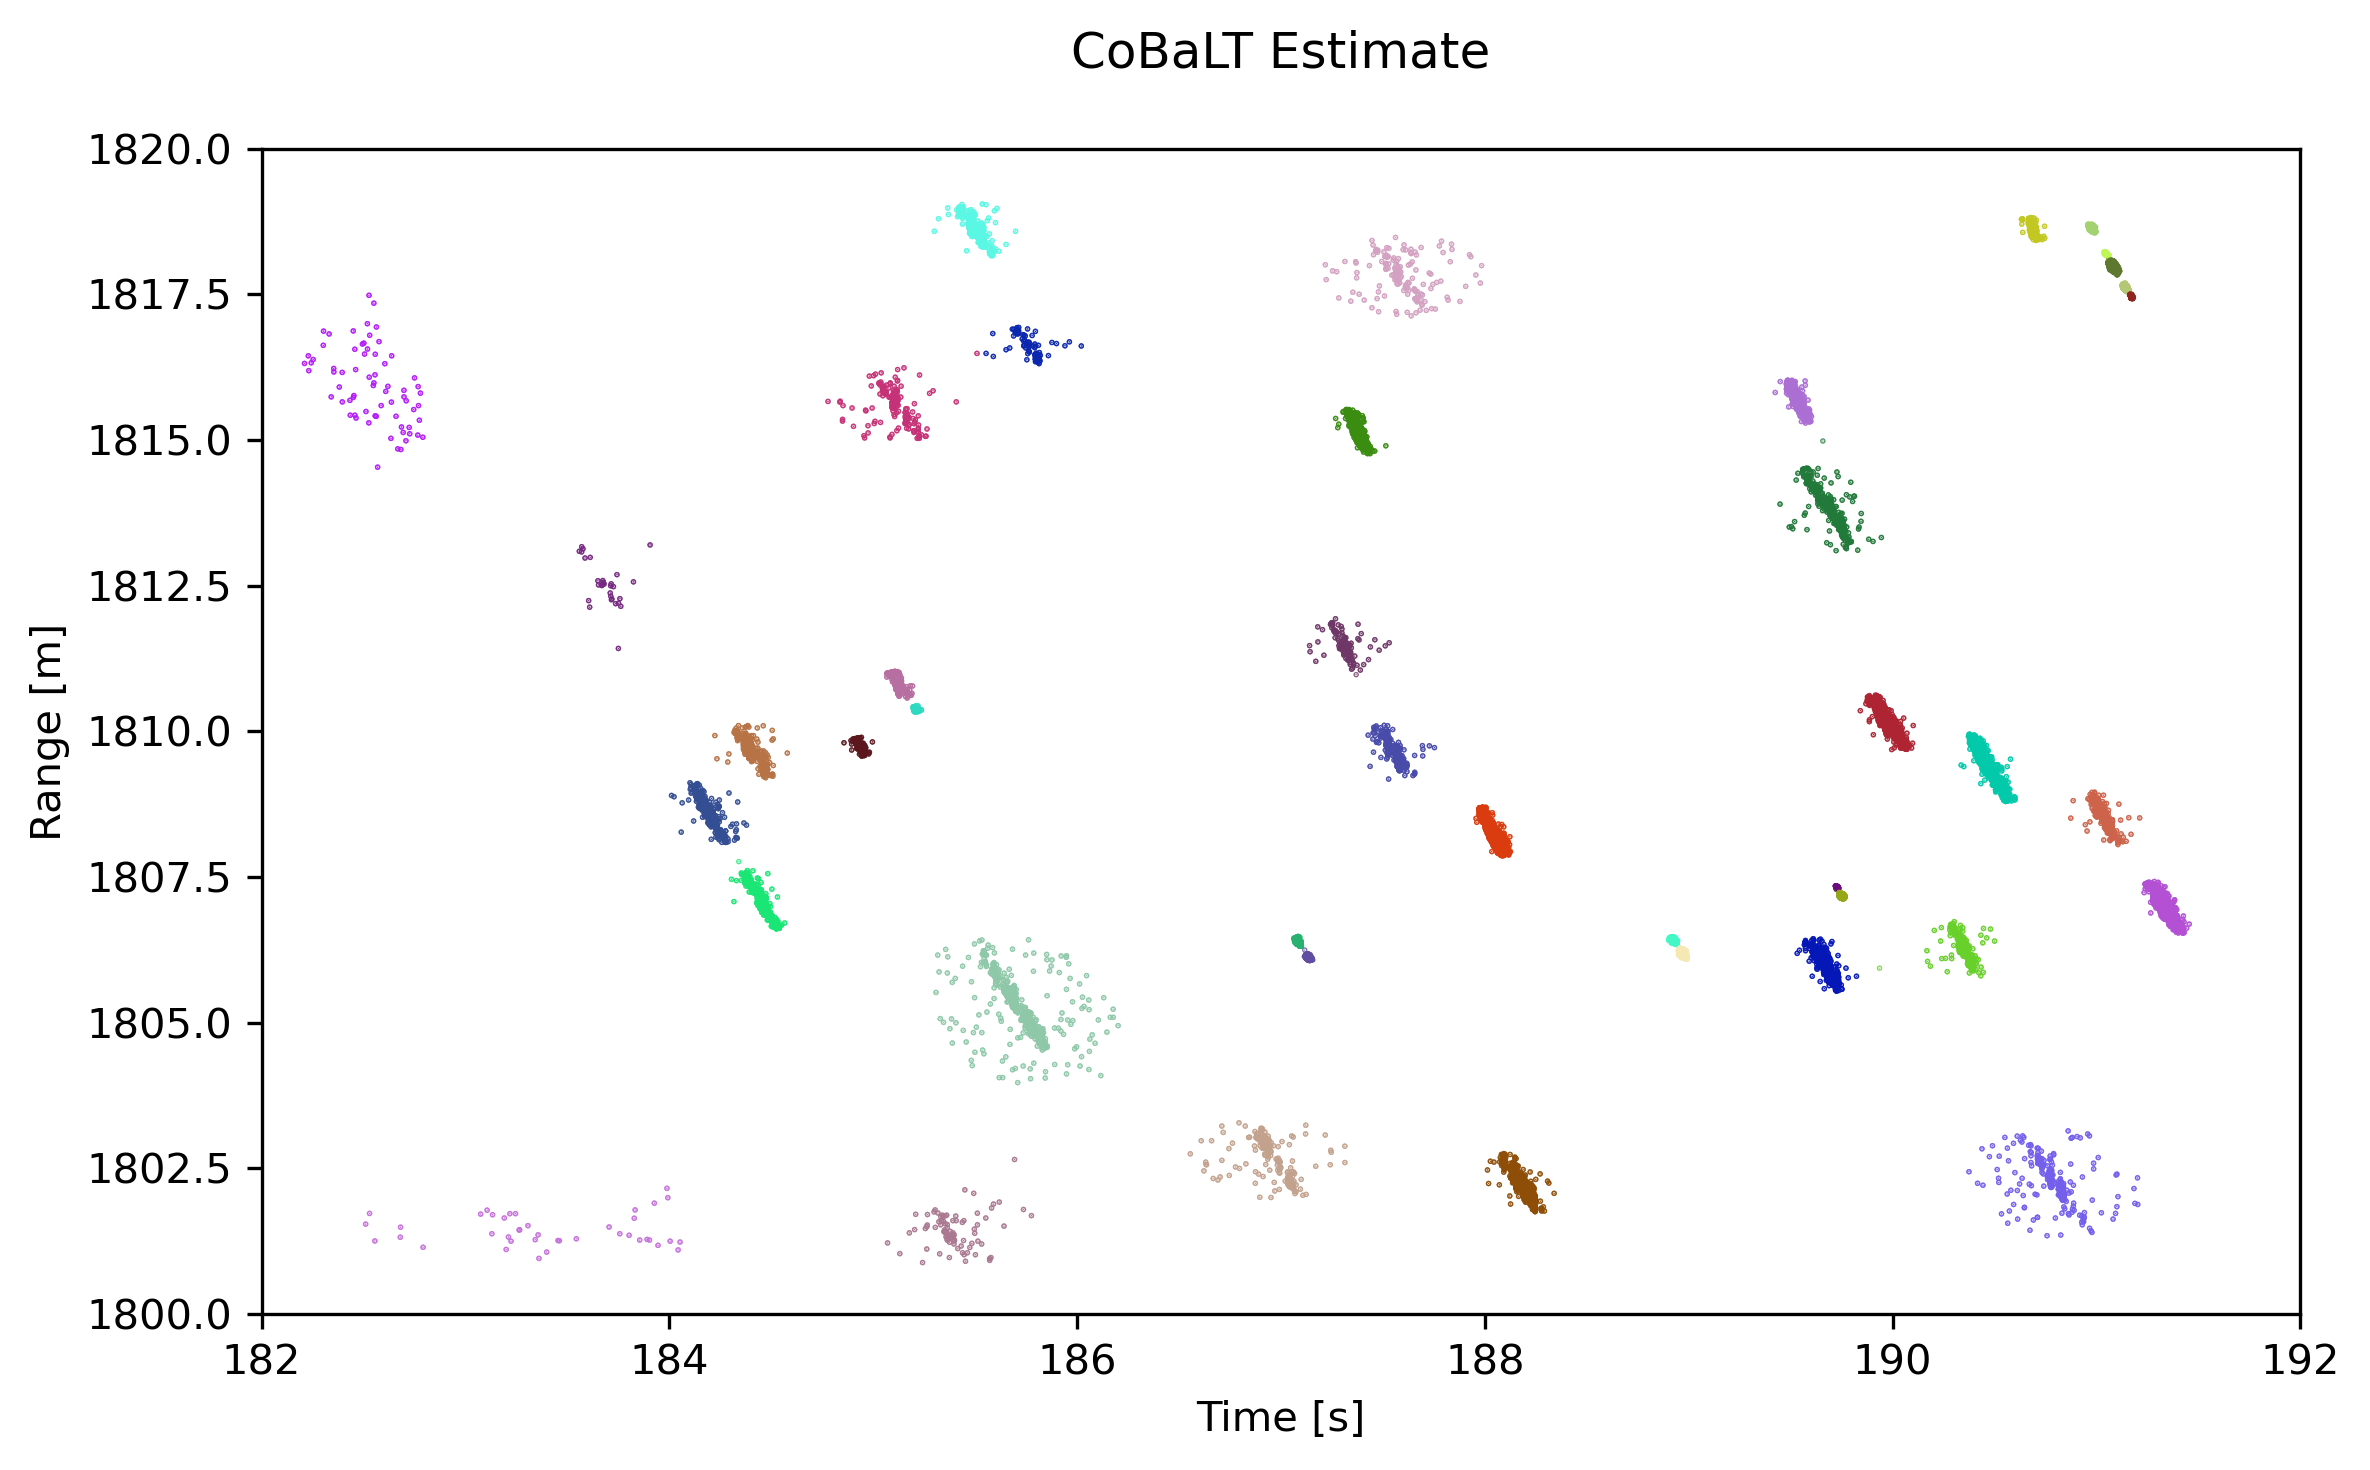

In [104]:
p_colors_denoised = point_colors[labels != -1]
X_denoised = X_original[labels != -1]

fig = plt.figure(figsize=(8, 5), dpi=300)
ax = fig.add_subplot(111)
scatter = ax.scatter(X_denoised[:, 0], X_denoised[:, 1], c=p_colors_denoised, cmap='viridis', s=0.1, alpha=0.8)
ax.set_title('CoBaLT Estimate\n')
ax.set_ylabel('Range [m]')
ax.set_xlabel('Time [s]')
ax.set_xlim([t0, t1])
ax.set_ylim([r0, r1])

plt.tight_layout()
plt.show()

In [105]:
from sklearn.mixture import GaussianMixture

def gmm_est(X, Kmin=1, Kmax=12):
    gmms = []
    scores = []    
    for k in range(Kmin, Kmax + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            reg_covar=1e-4,
            n_init=1
        )
        gmm.fit(X)
        score = gmm.score(X)
        
        gmms.append(gmm)
        scores.append(score)
    return gmms, scores



In [106]:
Kmin = 50
Kmax = 50
ks = range(Kmin, Kmax + 1)
print('K_min={}, K_max={}'.format(Kmin, Kmax))

start = time.time()
# gmms, score_gmm = gmm_est(CoBaLT_blobs, Kmin, Kmax)
gmms_dn, score_gmm_dn = gmm_est(X_denoised, Kmin, Kmax)
print('Num points: {}'.format(X_denoised.size))
print('Time elapsed: {:.2f} s'.format(time.time() - start))
# start = time.time()
# gmms, score_gmm = gmm_est(X_original, Kmin, Kmax)
# print('Num points: {}'.format(X_original.size))
# print('Time elapsed: {:.2f} s'.format(time.time() - start))

K_min=50, K_max=50
Num points: 55922
Time elapsed: 6.06 s


In [107]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def draw_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )
    ax.add_patch(ellipse)

In [108]:
K_best = ks[np.argmax(score_gmm)]
gmm_best = gmms[np.argmax(score_gmm)]
K_best_dn = ks[np.argmax(score_gmm_dn)]
gmm_best_dn = gmms_dn[np.argmax(score_gmm_dn)]

# if gmms[0].covariance_type == 'diag':
#     gmm_best.covariances_ = np.array([np.diag(row) for row in gmm_best.covariances_])

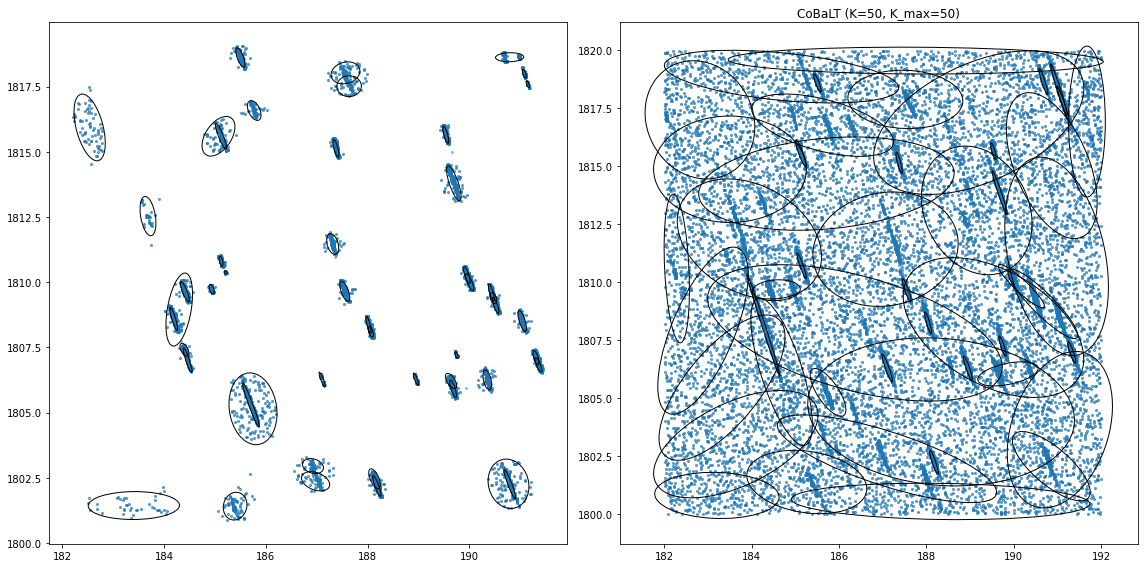

In [109]:
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(121)
ax1.scatter(X_denoised[:, 0], X_denoised[:, 1], s=4, alpha=0.4)
for mean, cov in zip(gmm_best_dn.means_, gmm_best_dn.covariances_):
    draw_ellipse(mean, cov, ax1)
ax2 = fig.add_subplot(122)
ax2.scatter(X_original[:, 0], X_original[:, 1], s=4, alpha=0.4)
for mean, cov in zip(gmm_best.means_, gmm_best.covariances_):
    draw_ellipse(mean, cov, ax2)
plt.title("CoBaLT (K={}, K_max={})".format(K_best, Kmax))
# ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [110]:
S_dn = gmm_best_dn.covariances_
Sxy_dn = S_dn[:, 0, 1]  # [m s]
Sx_dn = np.sqrt(S_dn[:, 0, 0])  # [m]
beta_hat_dn = Sxy_dn / Sx_dn**2  # [m/s]

S = gmm_best.covariances_
Sxy = S[:, 0, 1]  # [m s]
Sx = np.sqrt(S[:, 0, 0])  # [m]
beta_hat = Sxy / Sx**2  # [m/s]
# print('Slope estimate (denoised) [m/s]: {}'.format(beta_hat_dn[beta_hat_dn < 0]))
# print('Slope estimate (raw) [m/s]: {}'.format(beta_hat[beta_hat < 0]))

beta_hat_dn_neg = beta_hat_dn[beta_hat_dn < 0]
sort_idx = np.argsort(beta_hat_dn_neg)
thresh = -1

gmm_best_dn_means_viable = gmm_best_dn.means_[beta_hat_dn < thresh]
gmm_best_dn_cov_viable = gmm_best_dn.covariances_[beta_hat_dn < thresh]

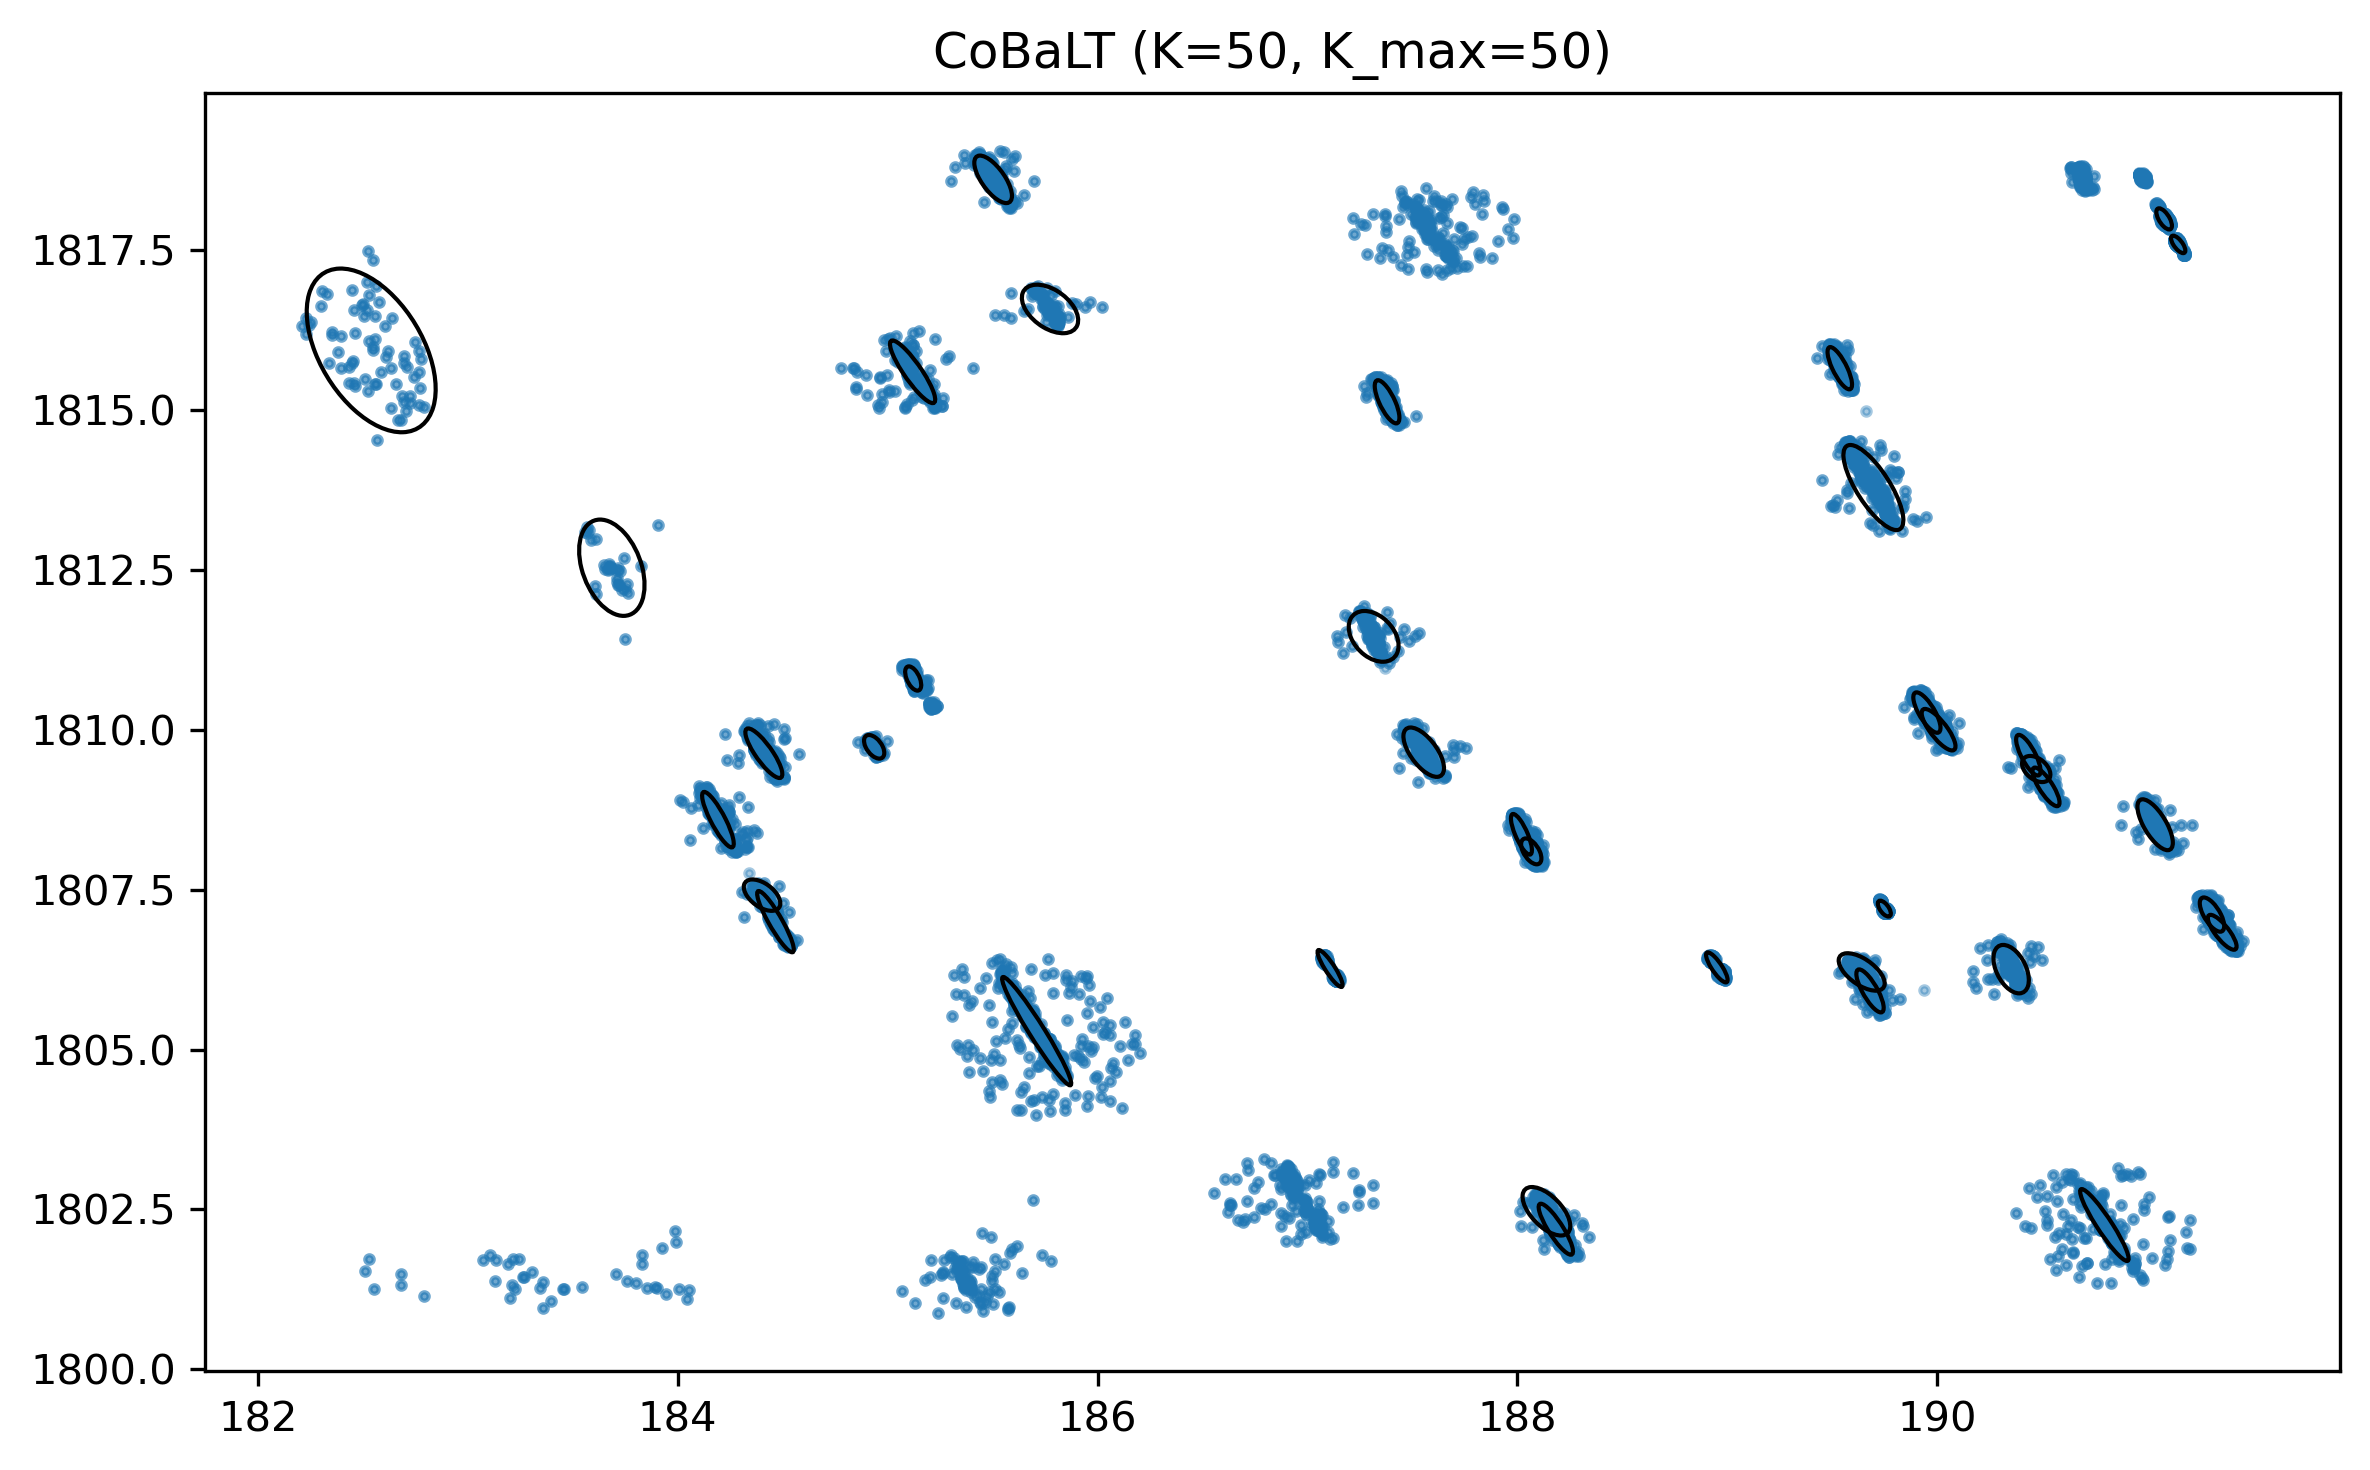

In [111]:
fig = plt.figure(figsize=(8, 5), dpi=300)
ax1 = fig.add_subplot(111)
ax1.scatter(X_denoised[:, 0], X_denoised[:, 1], s=4, alpha=0.4)
for mean, cov in zip(gmm_best_dn_means_viable, gmm_best_dn_cov_viable):
    draw_ellipse(mean, cov, ax1)
ax1.set_title("CoBaLT (K={}, K_max={})".format(K_best_dn, Kmax))
# ax2 = fig.add_subplot(122)
# ax2.scatter(X_original[:, 0], X_original[:, 1], s=4, alpha=0.4)
# for mean, cov in zip(gmm_best.means_, gmm_best.covariances_):
#     draw_ellipse(mean, cov, ax2)
# ax2.set_title("CoBaLT (K={}, K_max={})".format(K_best, Kmax))
# ax.set_aspect('equal')

plt.tight_layout()
plt.show()